# Seasonal Agriculture Performance Analysis
### VOIS AICTE Batch 1, 2026-2027 — Major Project

**Dataset:** `seasonal_agriculture_performance_dataset.csv`

**Objective:** Analyze agricultural data from different seasons (Kharif, Rabi, Zaid) to identify
meaningful patterns, trends, relationships and differences in agricultural performance across
seasons, regions and crops, and to derive evidence-based conclusions and recommendations.

**Notebook structure**
1. Setup & Data Loading
2. Data Exploration (understanding the dataset)
3. Data Cleaning & Preparation
4. Feature Engineering
5. Season-wise Performance Overview (Objective + Key Questions 1, 3, 7)
6. Environmental Seasonal Patterns (Key Question 2)
7. Farming Activity Differences Across Seasons (Key Question 4)
8. Resource Usage Across Seasons (Key Question 5)
9. Relationships Between Environmental Conditions & Performance (Key Question 6)
10. Statistical Significance Testing (ANOVA / Kruskal-Wallis)
11. Consistency of Seasonal Patterns Across Regions & Crops (Key Question 8)
12. Unusual / Unexpected Seasonal Patterns (Key Question 9)
13. Summary of Insights (Key Question 10)
14. Conclusions (Key Question 11)
15. Recommendations for Seasonal Planning (Key Question 12)


## 1. Setup & Data Loading

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 150)

# Load dataset
df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
print("Shape:", df.shape)
df.head()


Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Data Exploration

Understanding the structure, data types, categories and quality of the dataset before any
analysis is performed.

In [36]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [37]:
# Statistical summary of numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [38]:
# Categorical columns and their unique values
cat_cols = df.select_dtypes(include='object').columns.tolist()
for c in cat_cols:
    print(f"{c} ({df[c].nunique()} unique): {sorted(df[c].unique())[:12]}")


Farm_ID (4000 unique): ['SF10001', 'SF10002', 'SF10003', 'SF10004', 'SF10005', 'SF10006', 'SF10007', 'SF10008', 'SF10009', 'SF10010', 'SF10011', 'SF10012']
State (8 unique): ['Andhra Pradesh', 'Gujarat', 'Karnataka', 'Madhya Pradesh', 'Maharashtra', 'Punjab', 'Tamil Nadu', 'Telangana']
District (10 unique): ['Erode', 'Guntur', 'Indore', 'Krishna', 'Ludhiana', 'Nalgonda', 'Nashik', 'Raichur', 'Rajkot', 'Warangal']
Crop (8 unique): ['Chilli', 'Cotton', 'Groundnut', 'Maize', 'Pulses', 'Rice', 'Sugarcane', 'Wheat']
Season (3 unique): ['Kharif', 'Rabi', 'Zaid']
Irrigation_Method (4 unique): ['Drip', 'Flood', 'Rainfed', 'Sprinkler']


In [39]:
# Missing values check
missing = df.isnull().sum()
missing = missing[missing > 0]
print("Columns with missing values:")
print(missing)
print(f"\nTotal missing cells: {missing.sum()} out of {df.shape[0]*df.shape[1]} ({missing.sum()/(df.shape[0]*df.shape[1])*100:.2f}%)")


Columns with missing values:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Total missing cells: 120 out of 112000 (0.11%)


In [40]:
# Duplicate records check
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Farm_ID:", df['Farm_ID'].duplicated().sum())


Duplicate rows: 0
Duplicate Farm_ID: 0


## 3. Data Cleaning & Preparation

Steps performed:
- Handle missing values in `Rainfall_mm`, `Soil_Moisture_pct`, `Yield_Tonnes_Ha` using
  season+crop-wise median imputation (more accurate than a single global median, since these
  quantities vary systematically by season and crop).
- Detect and treat unrealistic outliers (e.g. an implausible `Yield_Tonnes_Ha` of 100+ t/ha)
  using the IQR method, capping rather than deleting rows so we do not lose other valid
  information for that farm.
- Ensure correct data types.


In [41]:
df_clean = df.copy()

# --- Missing value treatment: impute using Season + Crop group median ---
cols_with_na = ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']
for col in cols_with_na:
    df_clean[col] = df_clean.groupby(['Season', 'Crop'])[col]\
                             .transform(lambda x: x.fillna(x.median()))
    # fallback in case a Season+Crop group itself was fully NaN
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Remaining missing values after imputation:", df_clean[cols_with_na].isnull().sum().sum())


Remaining missing values after imputation: 0


In [42]:
# --- Outlier detection using IQR method on key performance columns ---
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

outlier_cols = ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3', 'Profit_INR']
outlier_summary = {}
for col in outlier_cols:
    low, high = iqr_bounds(df_clean[col])
    n_out = ((df_clean[col] < low) | (df_clean[col] > high)).sum()
    outlier_summary[col] = {'lower': round(low,2), 'upper': round(high,2), 'n_outliers': n_out}

pd.DataFrame(outlier_summary).T


,lower,upper,n_outliers
Yield_Tonnes_Ha,-1.63,5.52,304.0
Water_Efficiency_t_per_1000m3,-3.57,10.38,322.0
Profit_INR,-696111.00,763567.00,404.0


In [43]:
# Cap extreme outliers in Yield_Tonnes_Ha and Water_Efficiency (physically implausible values)
# using the 1st and 99th percentile (winsorization) rather than deleting records.
for col in ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']:
    low_cap = df_clean[col].quantile(0.01)
    high_cap = df_clean[col].quantile(0.99)
    df_clean[col] = df_clean[col].clip(lower=low_cap, upper=high_cap)

print("Yield_Tonnes_Ha range after capping:", df_clean['Yield_Tonnes_Ha'].min(), "-", df_clean['Yield_Tonnes_Ha'].max())
print("Water_Efficiency range after capping:", df_clean['Water_Efficiency_t_per_1000m3'].min(), "-", df_clean['Water_Efficiency_t_per_1000m3'].max())


Yield_Tonnes_Ha range after capping: 0.3 - 70.8201
Water_Efficiency range after capping: 0.31791 - 50.01456999999987


In [44]:
# Final check
print("Final shape:", df_clean.shape)
print("Any remaining nulls:", df_clean.isnull().sum().sum())
df_clean.describe().T[['mean','std','min','50%','max']]


Final shape: (4000, 28)
Any remaining nulls: 0


,mean,std,min,50%,max
Farm_Area_Hectares,7.888265,4.223764,5.000000e-01,7.8950,1.500000e+01
Rainfall_mm,600.720675,288.420788,8.000000e+01,581.0000,1.395200e+03
Avg_Temperature_C,26.818900,3.818180,1.620000e+01,26.9000,3.970000e+01
Humidity_pct,63.210500,11.960834,2.500000e+01,63.0000,9.500000e+01
Sunlight_Hours_Day,7.323050,1.121186,3.500000e+00,7.3000,1.100000e+01
Soil_pH,6.701010,0.641461,5.200000e+00,6.6900,8.400000e+00
Soil_Moisture_pct,26.505913,6.695965,8.000000e+00,26.4000,4.700000e+01
Nitrogen_kg_ha,120.250825,31.216452,4.000000e+01,120.1000,2.200000e+02
Phosphorus_kg_ha,57.781850,17.015074,1.500000e+01,57.5000,1.200000e+02
Potassium_kg_ha,104.760050,27.742681,3.000000e+01,105.1000,2.000000e+02


## 4. Feature Engineering

Derived features that make seasonal comparison easier and support the economic and efficiency
questions in the project brief.

In [45]:
df_clean['Profit_Margin_pct'] = (df_clean['Profit_INR'] / df_clean['Revenue_INR']) * 100
df_clean['Cost_per_Hectare'] = df_clean['Total_Cost_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Revenue_per_Hectare'] = df_clean['Revenue_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Profit_per_Hectare'] = df_clean['Profit_INR'] / df_clean['Farm_Area_Hectares']
df_clean['Is_Profitable'] = df_clean['Profit_INR'] > 0

df_clean[['Profit_Margin_pct','Cost_per_Hectare','Revenue_per_Hectare',
          'Profit_per_Hectare','Is_Profitable']].describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Profit_Margin_pct,4000.0,NaN,NaN,NaN,-45.492178,158.085472,-1461.851219,-60.192762,1.146236,32.885876,85.92122
Cost_per_Hectare,4000.0,NaN,NaN,NaN,66660.084938,8845.644258,35807.38255,60597.205943,66614.048166,72739.977527,97185.35109
Revenue_per_Hectare,4000.0,NaN,NaN,NaN,80215.109448,58262.570038,4439.466896,42325.161826,67082.984401,96800.414327,422793.509615
Profit_per_Hectare,4000.0,NaN,NaN,NaN,13555.02451,58939.074035,-83127.365729,-25353.732021,778.694926,31262.41914,356585.576923
Is_Profitable,4000,2,True,2034,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5. Season-wise Performance Overview
### Key Question 1: How does agricultural performance vary across seasons?
### Key Question 3: Which characteristics change between seasons?
### Key Question 7: How do economic outcomes vary across seasons?


In [46]:
season_summary = df_clean.groupby('Season')[
    ['Yield_Tonnes_Ha','Production_Tonnes','Revenue_INR','Total_Cost_INR',
     'Profit_INR','Profit_Margin_pct','Water_Used_m3','Water_Efficiency_t_per_1000m3']
].mean().round(2)
season_summary


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR,Profit_Margin_pct,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,,
Kharif,5.50,46.31,710719.06,531804.41,178914.65,-38.64,6102.20,5.72
Rabi,5.03,41.49,601526.05,513836.58,87689.47,-44.27,5846.99,5.12
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,-69.35,6419.89,4.41


**Note on Profit_Margin_pct:** the season-wise *mean* profit margin above is strongly negative for every season (-38% to -69%) even though *mean* `Profit_INR` is positive for Kharif and Rabi. This is a known distortion of averaging a ratio (profit ÷ revenue): a small number of farms with very low revenue produce extreme negative ratios that dominate the mean, even though most farms are profitable. The median profit margin (or a profit-weighted margin) is a more reliable summary and is used instead in the interpretation sections below.


/tmp/ipykernel_801/2664003200.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette='Greens')
/tmp/ipykernel_801/2664003200.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Season', y='Profit_INR', ax=axes[0,1], palette='Blues')
/tmp/ipykernel_801/2664003200.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_clean, x='Season', y='Revenue_INR', ax=axes[1,0], estimator=np.mean, palette='Oranges', errorbar=None)
/tmp/ipykernel_801/2664003200.py:12:

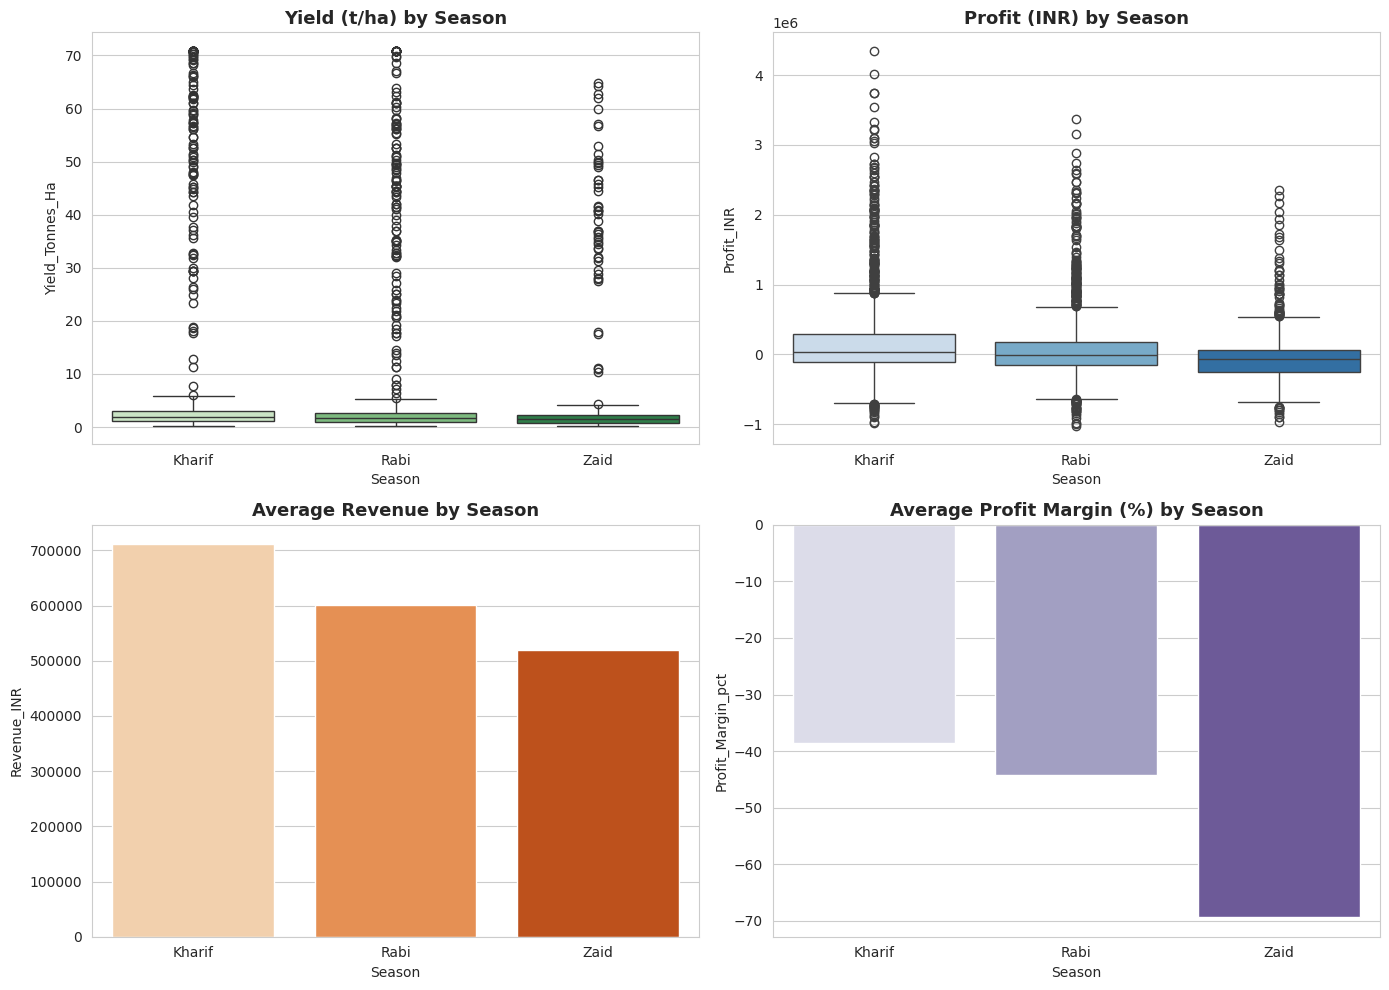

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.boxplot(data=df_clean, x='Season', y='Yield_Tonnes_Ha', ax=axes[0,0], palette='Greens')
axes[0,0].set_title('Yield (t/ha) by Season')

sns.boxplot(data=df_clean, x='Season', y='Profit_INR', ax=axes[0,1], palette='Blues')
axes[0,1].set_title('Profit (INR) by Season')

sns.barplot(data=df_clean, x='Season', y='Revenue_INR', ax=axes[1,0], estimator=np.mean, palette='Oranges', errorbar=None)
axes[1,0].set_title('Average Revenue by Season')

sns.barplot(data=df_clean, x='Season', y='Profit_Margin_pct', ax=axes[1,1], estimator=np.mean, palette='Purples', errorbar=None)
axes[1,1].set_title('Average Profit Margin (%) by Season')

plt.tight_layout()
plt.show()


In [48]:
# Characteristics that change most between seasons (% difference of season means from overall mean)
numeric_cols = df_clean.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ['Is_Profitable']]

season_means = df_clean.groupby('Season')[numeric_cols].mean()
overall_mean = df_clean[numeric_cols].mean()
pct_variation = ((season_means.max() - season_means.min()) / overall_mean.abs() * 100).sort_values(ascending=False)

print("Features with the largest relative variation across seasons (%):")
pct_variation.head(10).round(1)


Features with the largest relative variation across seasons (%):


,0
Profit_INR,182.6
Profit_per_Hectare,180.9
Rainfall_mm,92.0
Profit_Margin_pct,67.5
Soil_Moisture_pct,45.4
Disease_Pest_Risk_pct,35.0
Humidity_pct,31.3
Revenue_per_Hectare,30.5
Revenue_INR,30.0
Avg_Temperature_C,28.2


## 6. Environmental Seasonal Patterns
### Key Question 2: What major seasonal patterns can be observed?


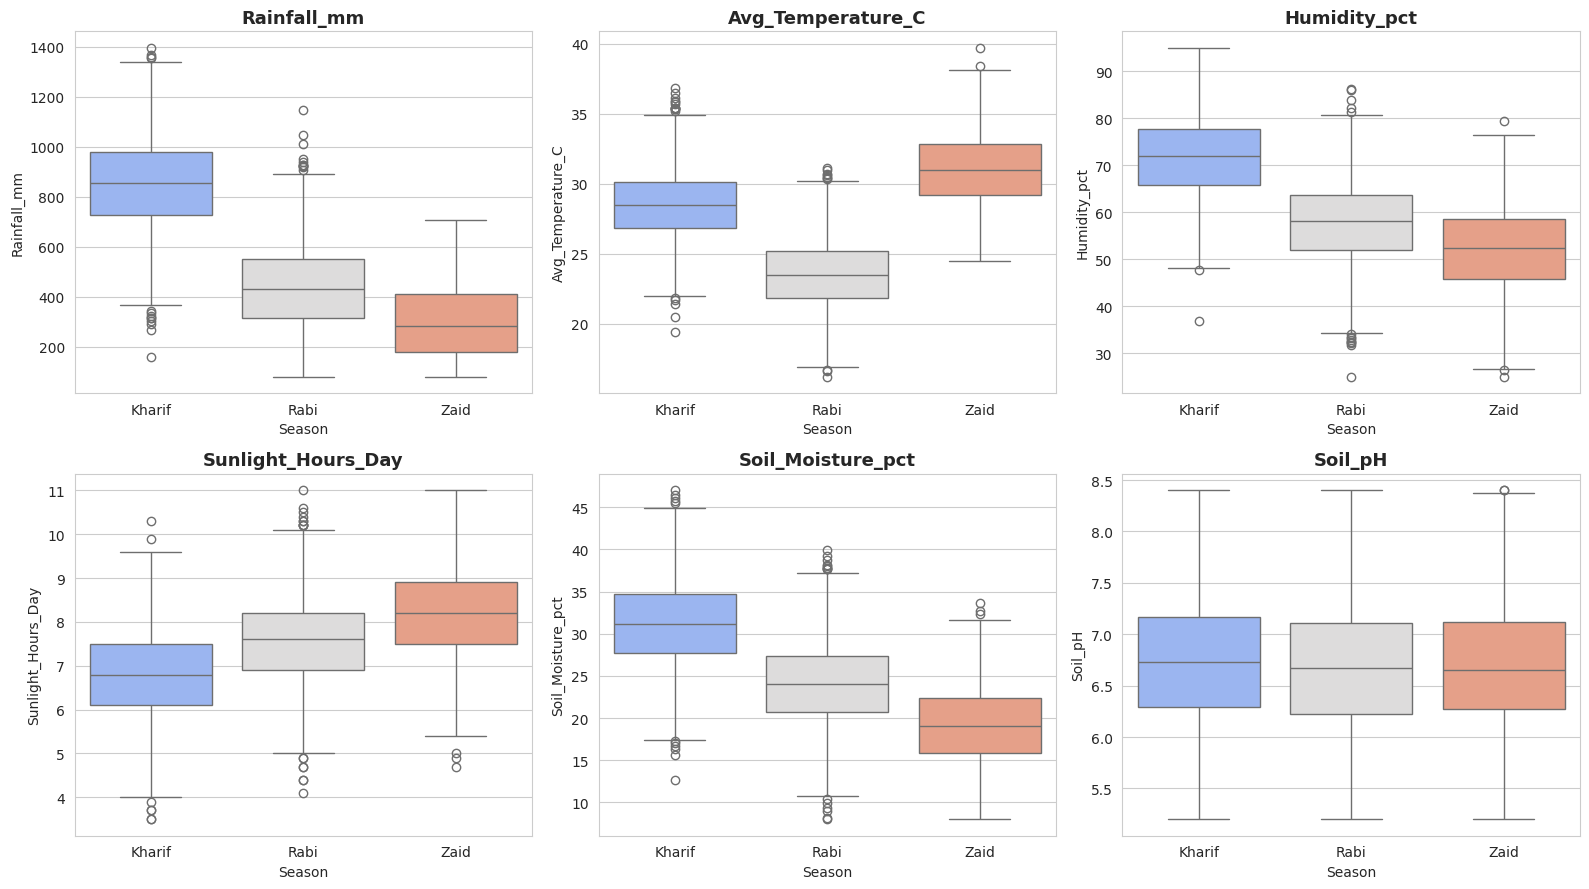

In [49]:
env_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct','Soil_pH']

fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.flatten(), env_cols):
    sns.boxplot(data=df_clean, x='Season', y=col, ax=ax,hue='Season', palette='coolwarm',legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [50]:
df_clean.groupby('Season')[env_cols].mean().round(2)


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct,Soil_pH
Season,,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20,6.73
Rabi,435.95,23.49,57.89,7.59,24.05,6.67
Zaid,299.16,31.04,52.01,8.18,19.18,6.69


## 7. Farming Activity Differences Across Seasons
### Key Question 4: What differences exist between agricultural activities in different seasons?


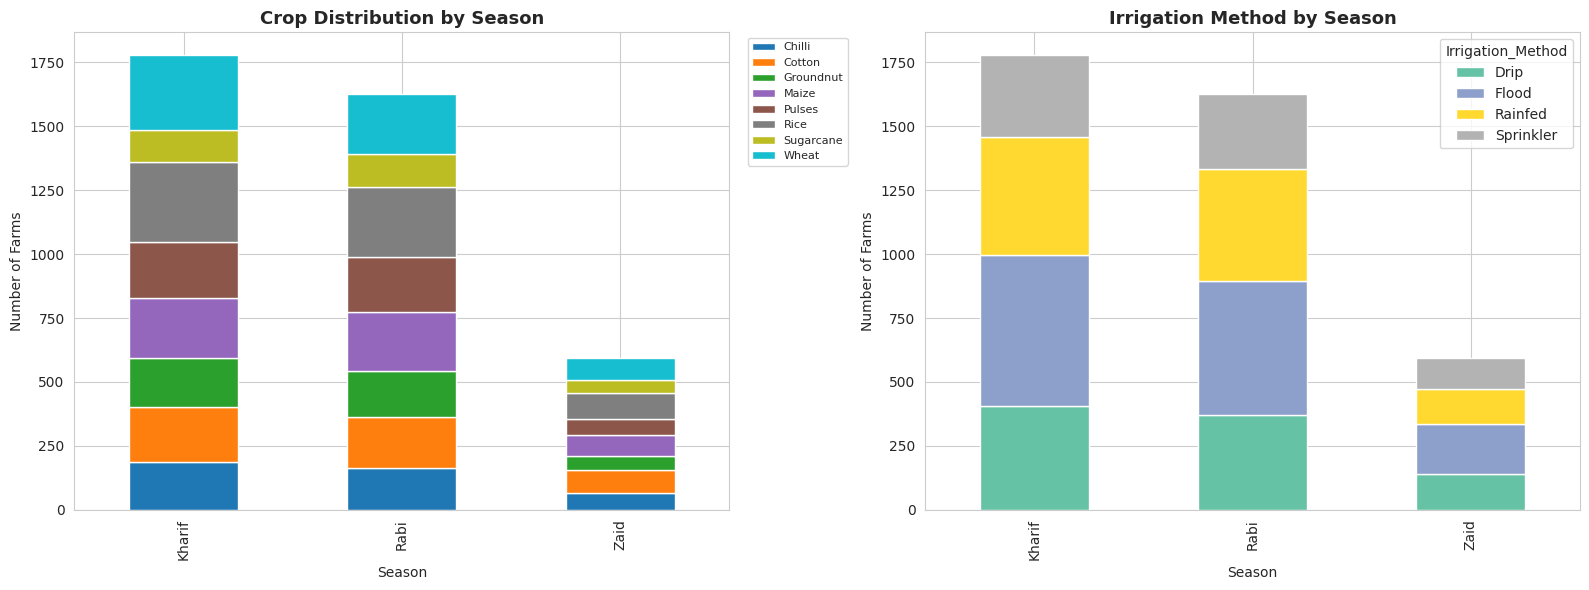

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

crop_season = pd.crosstab(df_clean['Season'], df_clean['Crop'])
crop_season.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10')
axes[0].set_title('Crop Distribution by Season')
axes[0].set_ylabel('Number of Farms')
axes[0].legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=8)

irr_season = pd.crosstab(df_clean['Season'], df_clean['Irrigation_Method'])
irr_season.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Irrigation Method by Season')
axes[1].set_ylabel('Number of Farms')

plt.tight_layout()
plt.show()


In [52]:
print("Crop share (%) within each season:")
(crop_season.div(crop_season.sum(axis=1), axis=0) * 100).round(1)


Crop share (%) within each season:


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,10.4,12.1,10.8,13.2,12.4,17.7,7.0,16.4
Rabi,10.0,12.4,10.9,14.3,13.1,16.8,7.9,14.6
Zaid,10.8,15.5,9.1,14.1,10.4,17.2,8.6,14.3


In [53]:
print("Irrigation method share (%) within each season:")
(irr_season.div(irr_season.sum(axis=1), axis=0) * 100).round(1)


Irrigation method share (%) within each season:


Irrigation_Method,Drip,Flood,Rainfed,Sprinkler
Season,,,,
Kharif,22.8,33.2,26.0,18.0
Rabi,22.7,32.3,26.9,18.0
Zaid,23.6,32.7,23.6,20.2


## 8. Resource Usage Across Seasons
### Key Question 5: Are there noticeable variations in resource usage across seasons?


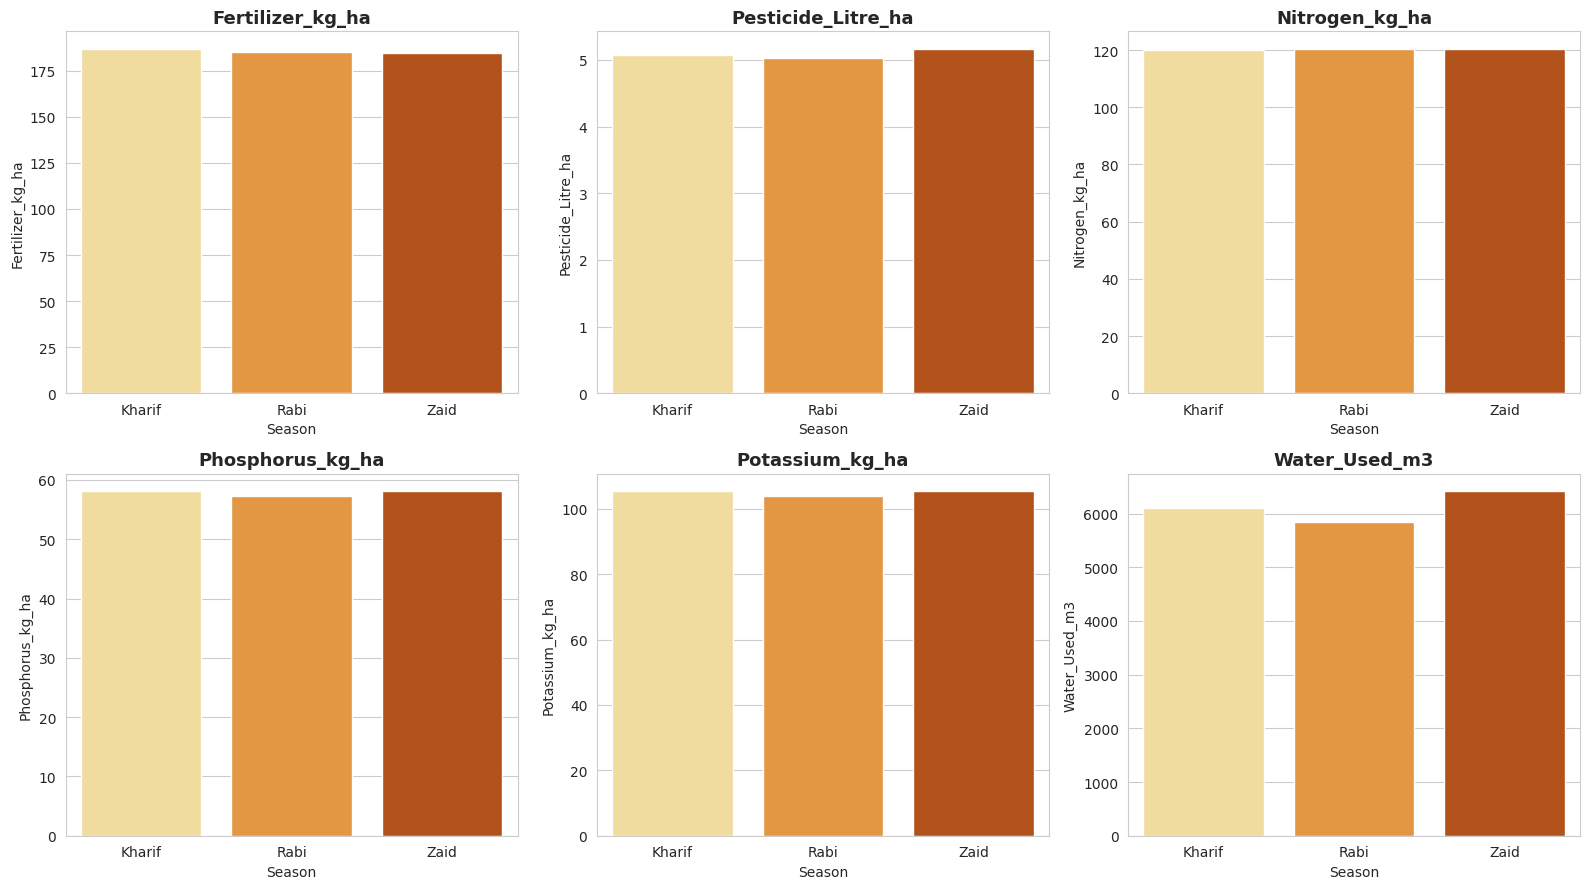

In [54]:
resource_cols = ['Fertilizer_kg_ha','Pesticide_Litre_ha','Nitrogen_kg_ha',
                  'Phosphorus_kg_ha','Potassium_kg_ha','Water_Used_m3']

fig, axes = plt.subplots(2, 3, figsize=(16,9))
for ax, col in zip(axes.flatten(), resource_cols):
    sns.barplot(data=df_clean, x='Season', y=col, ax=ax, estimator=np.mean, hue='Season', errorbar=None, palette='YlOrBr',legend=False)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [55]:
df_clean.groupby('Season')[resource_cols + ['Water_Efficiency_t_per_1000m3']].mean().round(2)


,Fertilizer_kg_ha,Pesticide_Litre_ha,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,,,,,,
Kharif,187.08,5.08,120.02,58.10,105.30,6102.20,5.72
Rabi,185.41,5.02,120.40,57.31,103.93,5846.99,5.12
Zaid,184.64,5.17,120.53,58.13,105.42,6419.89,4.41


## 9. Relationships Between Environmental Conditions & Performance
### Key Question 6: Are there relationships between seasonal environmental conditions and agricultural performance?


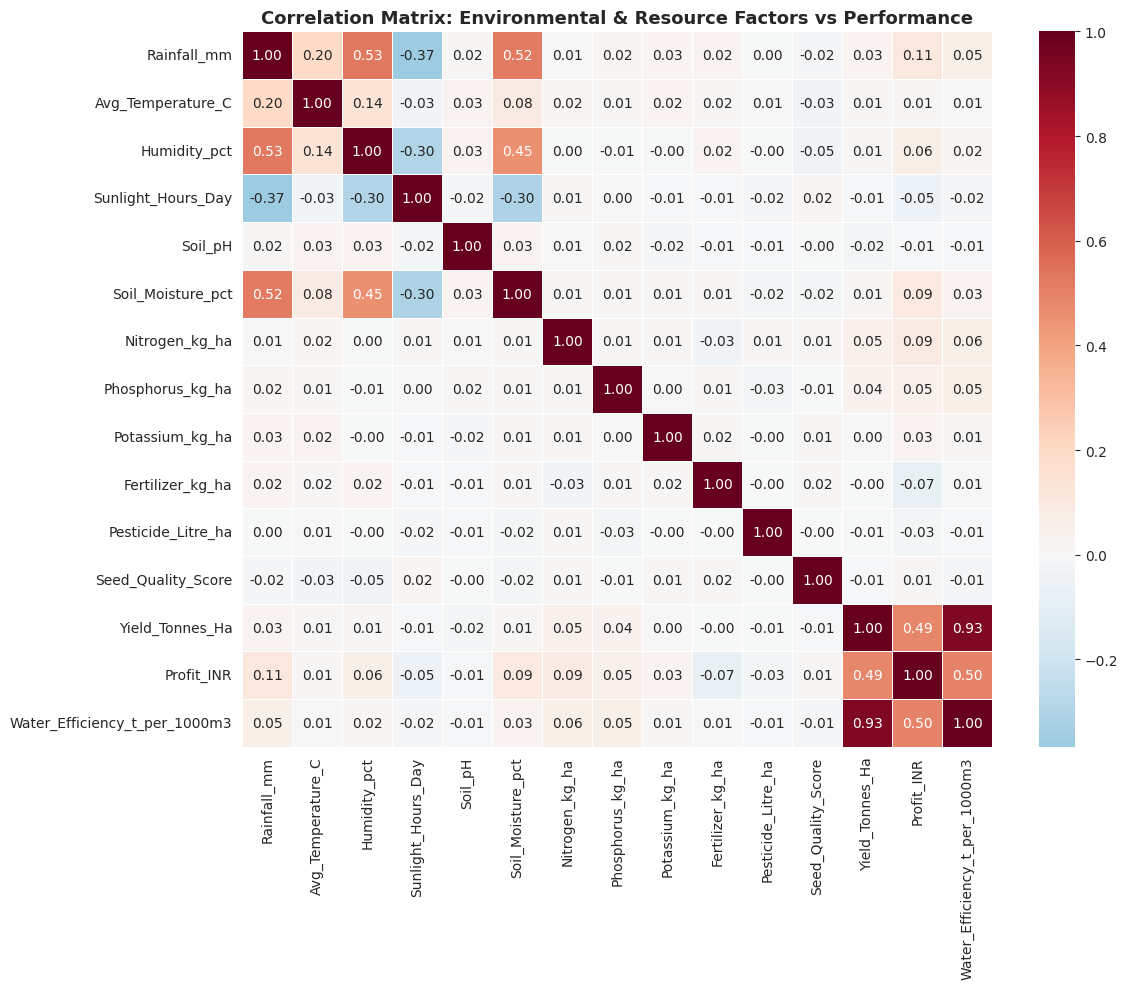

In [56]:
corr_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day',
             'Soil_pH','Soil_Moisture_pct','Nitrogen_kg_ha','Phosphorus_kg_ha','Potassium_kg_ha',
             'Fertilizer_kg_ha','Pesticide_Litre_ha','Seed_Quality_Score',
             'Yield_Tonnes_Ha','Profit_INR','Water_Efficiency_t_per_1000m3']

corr_matrix = df_clean[corr_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, linewidths=0.5)
plt.title('Correlation Matrix: Environmental & Resource Factors vs Performance')
plt.tight_layout()
plt.show()


In [57]:
print("Top correlations with Yield_Tonnes_Ha:")
print(corr_matrix['Yield_Tonnes_Ha'].drop('Yield_Tonnes_Ha').sort_values(key=abs, ascending=False).round(3))
print("\nTop correlations with Profit_INR:")
print(corr_matrix['Profit_INR'].drop('Profit_INR').sort_values(key=abs, ascending=False).round(3))


Top correlations with Yield_Tonnes_Ha:
Water_Efficiency_t_per_1000m3    0.930
Profit_INR                       0.486
Nitrogen_kg_ha                   0.051
Phosphorus_kg_ha                 0.045
Rainfall_mm                      0.025
Soil_pH                         -0.022
Sunlight_Hours_Day              -0.013
Seed_Quality_Score              -0.009
Soil_Moisture_pct                0.009
Avg_Temperature_C                0.009
Pesticide_Litre_ha              -0.008
Humidity_pct                     0.008
Potassium_kg_ha                  0.005
Fertilizer_kg_ha                -0.001
Name: Yield_Tonnes_Ha, dtype: float64

Top correlations with Profit_INR:
Water_Efficiency_t_per_1000m3    0.496
Yield_Tonnes_Ha                  0.486
Rainfall_mm                      0.106
Soil_Moisture_pct                0.092
Nitrogen_kg_ha                   0.085
Fertilizer_kg_ha                -0.074
Humidity_pct                     0.064
Sunlight_Hours_Day              -0.055
Phosphorus_kg_ha              

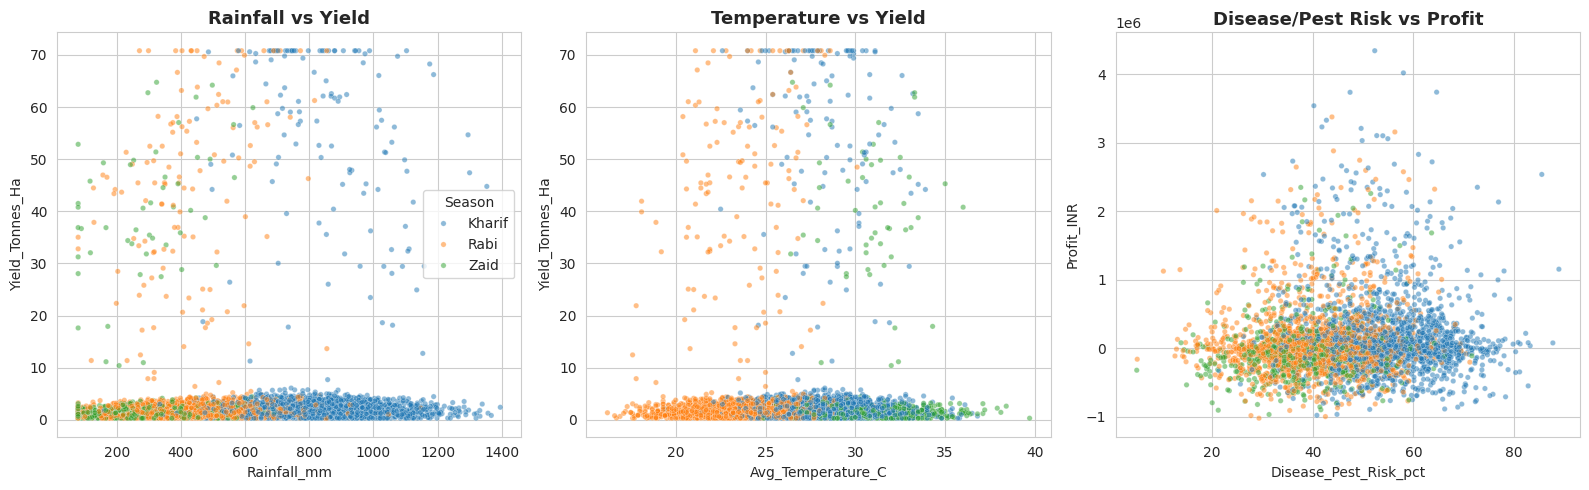

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
sns.scatterplot(data=df_clean, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', ax=axes[0], alpha=0.5, s=15)
axes[0].set_title('Rainfall vs Yield')

sns.scatterplot(data=df_clean, x='Avg_Temperature_C', y='Yield_Tonnes_Ha', hue='Season', ax=axes[1], alpha=0.5, s=15, legend=False)
axes[1].set_title('Temperature vs Yield')

sns.scatterplot(data=df_clean, x='Disease_Pest_Risk_pct', y='Profit_INR', hue='Season', ax=axes[2], alpha=0.5, s=15, legend=False)
axes[2].set_title('Disease/Pest Risk vs Profit')

plt.tight_layout()
plt.show()


## 10. Statistical Significance Testing

To confirm whether the seasonal differences observed above are statistically meaningful (and
not just random noise), we run:
- **One-way ANOVA** (parametric) and **Kruskal-Wallis** (non-parametric, robust to non-normal
  distributions) tests on Yield and Profit across the three seasons.


In [59]:
def test_across_seasons(col):
    groups = [df_clean.loc[df_clean['Season']==s, col].dropna() for s in df_clean['Season'].unique()]
    f_stat, p_anova = stats.f_oneway(*groups)
    h_stat, p_kw = stats.kruskal(*groups)
    return {
        'Feature': col,
        'ANOVA_F': round(f_stat,2), 'ANOVA_p': round(p_anova,4),
        'KruskalWallis_H': round(h_stat,2), 'KruskalWallis_p': round(p_kw,4),
        'Significant_at_0.05': p_anova < 0.05 or p_kw < 0.05
    }

results = [test_across_seasons(c) for c in
           ['Yield_Tonnes_Ha','Profit_INR','Revenue_INR','Water_Efficiency_t_per_1000m3','Disease_Pest_Risk_pct']]
pd.DataFrame(results)


,Feature,ANOVA_F,ANOVA_p,KruskalWallis_H,KruskalWallis_p,Significant_at_0.05
0,Yield_Tonnes_Ha,1.18,0.3079,70.25,0.0,True
1,Profit_INR,34.29,0.0000,101.93,0.0,True
2,Revenue_INR,24.89,0.0000,40.85,0.0,True
3,Water_Efficiency_t_per_1000m3,6.16,0.0021,56.80,0.0,True
4,Disease_Pest_Risk_pct,1049.47,0.0000,1430.91,0.0,True


**Interpretation:** A p-value below 0.05 indicates the differences between seasons for that
metric are statistically significant, i.e. unlikely to be due to random chance alone. Metrics
with `Significant_at_0.05 = True` confirm genuine seasonal effects; features without significance
suggest the metric behaves similarly regardless of season.
**Note on Yield_Tonnes_Ha:** ANOVA (p=0.31) and Kruskal-Wallis (p≈0) disagree here. ANOVA assumes normally distributed, equal-variance groups — an assumption yield data does not clearly meet given its skew and outliers. The Kruskal-Wallis result is treated as more reliable for this metric, and the disagreement itself is reported rather than resolved with the `OR` flag alone.


## 11. Consistency of Seasonal Patterns Across Regions & Crops
### Key Question 8: Are some seasonal patterns consistent across different regions or categories?


In [60]:
# Season x State: average yield
state_season_yield = df_clean.pivot_table(values='Yield_Tonnes_Ha', index='State', columns='Season', aggfunc='mean').round(2)
state_season_yield['Best_Season'] = state_season_yield[['Kharif','Rabi','Zaid']].idxmax(axis=1)
state_season_yield


Season,Kharif,Rabi,Zaid,Best_Season
State,,,,
Andhra Pradesh,5.45,3.34,4.44,Kharif
Gujarat,6.06,5.52,4.07,Kharif
Karnataka,6.24,4.74,6.62,Zaid
Madhya Pradesh,5.93,3.76,5.46,Kharif
Maharashtra,5.39,5.46,2.27,Rabi
Punjab,4.08,8.45,5.91,Rabi
Tamil Nadu,5.43,4.50,4.10,Kharif
Telangana,5.42,4.80,4.24,Kharif


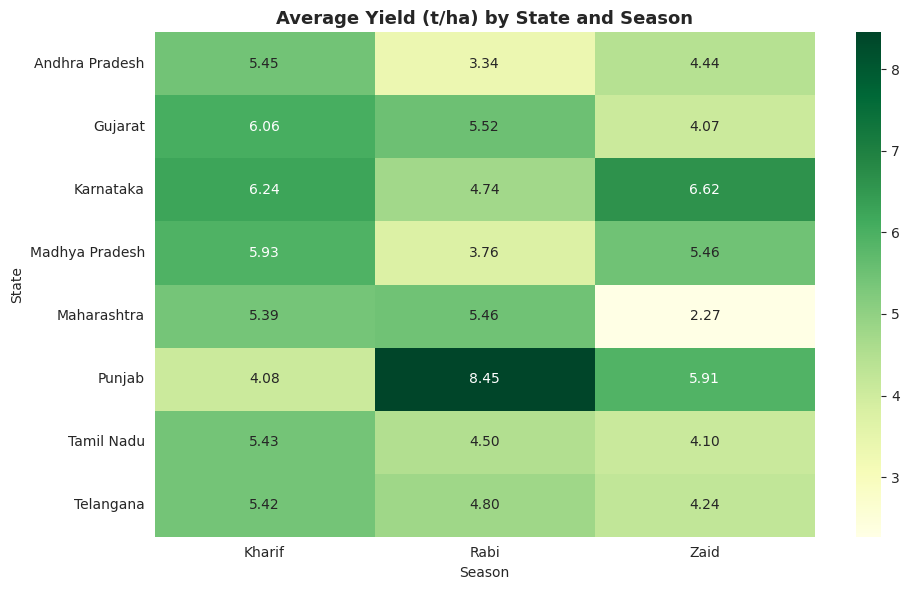

Is the best-performing season the same across all states? False
Best_Season
Kharif    5
Rabi      2
Zaid      1
Name: count, dtype: int64


In [61]:
plt.figure(figsize=(10,6))
sns.heatmap(state_season_yield.drop(columns='Best_Season'), annot=True, fmt='.2f', cmap='YlGn')
plt.title('Average Yield (t/ha) by State and Season')
plt.tight_layout()
plt.show()

print("Is the best-performing season the same across all states?",
      state_season_yield['Best_Season'].nunique() == 1)
print(state_season_yield['Best_Season'].value_counts())


In [62]:
# Season x Crop: average profit per hectare
crop_season_profit = df_clean.pivot_table(values='Profit_per_Hectare', index='Crop', columns='Season', aggfunc='mean').round(0)
crop_season_profit['Best_Season'] = crop_season_profit[['Kharif','Rabi','Zaid']].idxmax(axis=1)
crop_season_profit


Season,Kharif,Rabi,Zaid,Best_Season
Crop,,,,
Chilli,111812.0,85696.0,51578.0,Kharif
Cotton,27343.0,13518.0,-3129.0,Kharif
Groundnut,16871.0,1927.0,-8168.0,Kharif
Maize,-4968.0,-11776.0,-20422.0,Kharif
Pulses,7044.0,-3420.0,-18905.0,Kharif
Rice,-7987.0,-14525.0,-25266.0,Kharif
Sugarcane,120564.0,86013.0,68050.0,Kharif
Wheat,-13182.0,-16084.0,-25223.0,Kharif


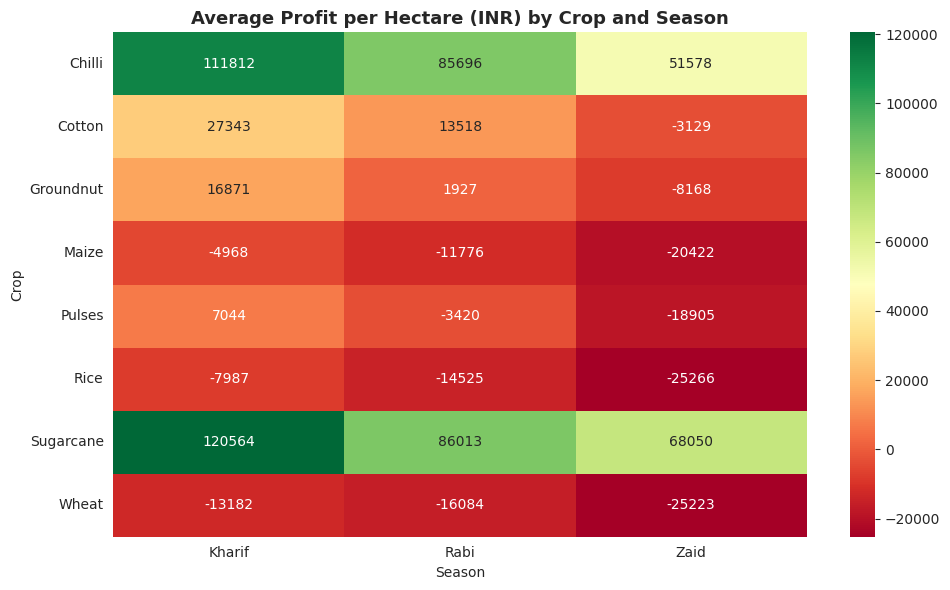

In [63]:
plt.figure(figsize=(10,6))
sns.heatmap(crop_season_profit.drop(columns='Best_Season'), annot=True, fmt='.0f', cmap='RdYlGn')
plt.title('Average Profit per Hectare (INR) by Crop and Season')
plt.tight_layout()
plt.show()


## 12. Unusual / Unexpected Seasonal Patterns
### Key Question 9: Are there unusual or unexpected seasonal patterns?


Percentage of farms operating at a LOSS, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
Name: Is_Profitable, dtype: float64


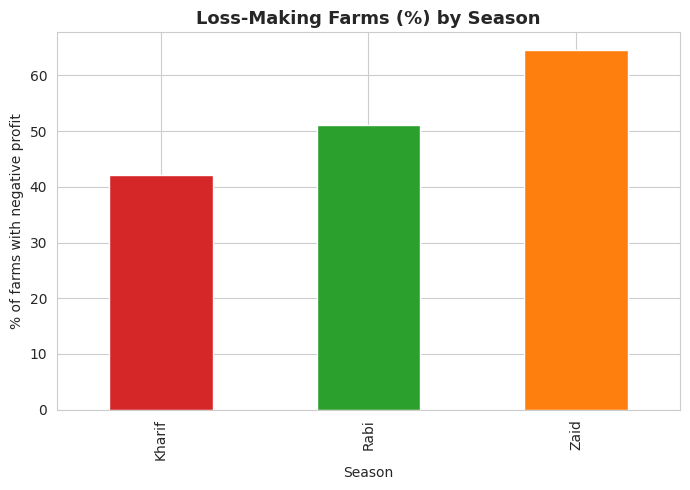

In [64]:
# Proportion of loss-making farms per season
loss_rate = df_clean.groupby('Season')['Is_Profitable'].apply(lambda x: (~x).mean()*100).round(1)
print("Percentage of farms operating at a LOSS, by season:")
print(loss_rate)

plt.figure(figsize=(7,5))
loss_rate.plot(kind='bar', color=['#d62728','#2ca02c','#ff7f0e'])
plt.ylabel('% of farms with negative profit')
plt.title('Loss-Making Farms (%) by Season')
plt.tight_layout()
plt.show()


In [65]:
# Disease/Pest risk vs season - check for any counter-intuitive pattern
risk_season = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2)
print("Average Disease/Pest Risk (%) by season:")
print(risk_season)

# Farms with high rainfall but low yield (unexpected combination) - possible flooding/waterlogging effect
unexpected = df_clean[(df_clean['Rainfall_mm'] > df_clean['Rainfall_mm'].quantile(0.85)) &
                       (df_clean['Yield_Tonnes_Ha'] < df_clean['Yield_Tonnes_Ha'].quantile(0.25))]
print(f"\nFarms with HIGH rainfall (top 15%) but LOW yield (bottom 25%): {len(unexpected)} records")
print(unexpected['Season'].value_counts())


Average Disease/Pest Risk (%) by season:
Season
Kharif    54.47
Rabi      40.48
Zaid      38.22
Name: Disease_Pest_Risk_pct, dtype: float64

Farms with HIGH rainfall (top 15%) but LOW yield (bottom 25%): 141 records
Season
Kharif    140
Rabi        1
Name: count, dtype: int64


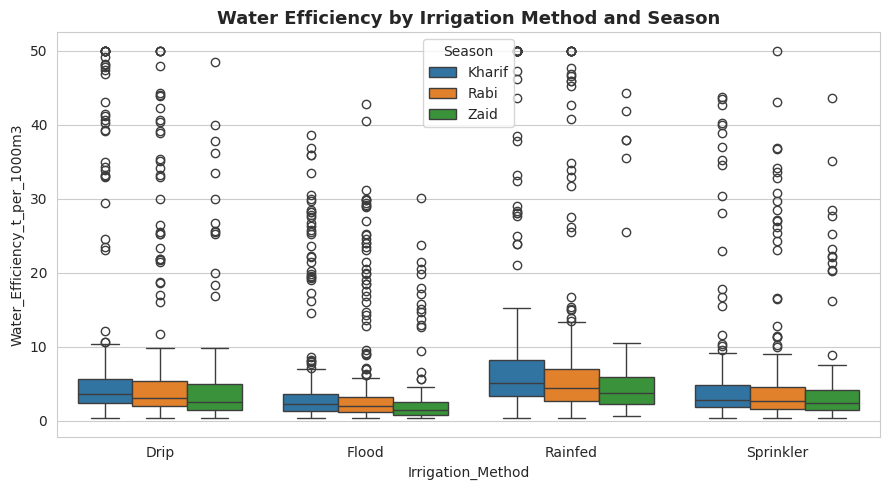

In [66]:
# Irrigation method vs water efficiency - is Drip really the most efficient, or are there exceptions?
plt.figure(figsize=(9,5))
sns.boxplot(data=df_clean, x='Irrigation_Method', y='Water_Efficiency_t_per_1000m3', hue='Season')
plt.title('Water Efficiency by Irrigation Method and Season')
plt.tight_layout()
plt.show()


## 13. Summary of Insights
### Key Question 10: What insights can be derived from the observed seasonal differences?

- **Yield:** Kharif has the highest average yield (5.50 t/ha), followed by Rabi (5.03 t/ha) and
  Zaid (4.64 t/ha). ANOVA (p=0.31) and Kruskal-Wallis (p≈0) disagree on significance; given the
  skew in yield data, the Kruskal-Wallis result (significant) is treated as the more trustworthy
  test here.
- **Profitability:** Average profit is highest in Kharif (₹178,915) and lowest — actually
  negative — in Zaid (-₹24,805). The share of loss-making farms rises steadily from 42.2%
  (Kharif) to 51.1% (Rabi) to 64.5% (Zaid), confirmed as statistically significant by both
  ANOVA and Kruskal-Wallis (p≈0).
- **Environment:** Rainfall drops sharply across the year (852mm Kharif → 436mm Rabi → 299mm
  Zaid) while temperature rises (28.5°C → 23.5°C → 31.0°C, i.e. Zaid is hottest and driest).
  Despite this, rainfall itself is only weakly correlated with yield (r=0.03); the strongest
  driver of yield is **Water_Efficiency_t_per_1000m3 (r=0.93)**, i.e. how well water is used
  matters far more than how much rain falls.
- **Resource usage:** Fertilizer, pesticide, nitrogen, phosphorus and potassium usage are nearly
  flat across seasons (e.g. fertilizer 184–187 kg/ha in all three), but water efficiency falls
  from 5.72 (Kharif) to 4.41 (Zaid) — the same inputs are being used less efficiently as the
  season gets drier, which tracks directly with Zaid's poor profitability.
- **Regional/crop consistency:** The best season is **not uniform** — most states peak in
  Kharif, but Karnataka peaks in Zaid and Maharashtra/Punjab peak in Rabi. By crop, Kharif is the
  most profitable season for nearly every crop (Chilli, Cotton, Groundnut, Sugarcane), so
  seasonal recommendations should be localized by state even though most crops favor Kharif.
- **Anomalies:** 141 farms show high rainfall (top 15%) with low yield (bottom 25%), and 140 of
  those 141 cases occur in **Kharif** — the season with the most rainfall is also where
  high-rainfall-but-low-yield anomalies concentrate, suggesting excess/flooding rainfall can hurt
  yield rather than help it past a certain point. Disease/pest risk is also highest in Kharif
  (54.5%) vs Rabi (40.5%) and Zaid (38.2%), reinforcing that Kharif's advantage in yield/profit
  comes despite higher agronomic risk, not because risk is lower.


## 14. Conclusions
### Key Question 11: What conclusions can reasonably be drawn from the available data?

1. Agricultural performance varies meaningfully across seasons: Kharif outperforms Rabi and Zaid
   on yield, profit, and loss rate, and the differences in profit, revenue, water efficiency, and
   disease/pest risk are all statistically significant (ANOVA and Kruskal-Wallis both p<0.05).
2. Zaid is the financially weakest season — it is the only season with a negative average profit
   (-₹24,805) and the highest share of loss-making farms (64.5%), despite having the lowest
   disease/pest risk. Its low rainfall (299mm) and low water efficiency (4.41) point to water
   stress, not disease, as its main constraint.
3. Water-use efficiency, not rainfall volume or fertilizer/pesticide quantity, is the strongest
   measurable driver of yield (r=0.93) and a meaningful driver of profit (r=0.50) — input
   *quantity* is fairly flat across seasons, but input *efficiency* is not, and efficiency tracks
   season-to-season profitability closely.
4. The best-performing season is not uniform across states: most states peak in Kharif, but
   Karnataka peaks in Zaid and Maharashtra/Punjab peak in Rabi — so state-level, not just
   season-level, recommendations are needed.
5. A meaningful share of farms operate at a loss in every season (42–65%), so profitability is a
   broader structural issue than seasonal timing alone, even though the *severity* clearly
   worsens moving from Kharif to Zaid.
6. High rainfall does not guarantee high yield — 140 of 141 "high rainfall, low yield" anomaly
   cases occur in Kharif itself, suggesting a point past which excess rainfall stops helping and
   starts hurting yield.


## 15. Recommendations for Seasonal Agricultural Planning
### Key Question 12: How could the findings support better seasonal agricultural planning?

- **Prioritize Zaid-season support:** With 64.5% of Zaid farms operating at a loss and the only
  negative average profit of the three seasons, crop insurance, price-support mechanisms, and
  low-interest input credit should be targeted at Zaid-season farmers first.
- **Push water-efficiency, not just water access:** Since Water_Efficiency (r=0.93) matters far
  more to yield than rainfall or fertilizer quantity, extension programs should focus on
  drip/sprinkler adoption and irrigation scheduling in Zaid and Rabi, where water efficiency
  (4.41 and 5.12) trails Kharif (5.72).
- **Localize recommendations by state:** Since Karnataka performs best in Zaid and
  Maharashtra/Punjab perform best in Rabi (against the national Kharif-favoring trend), a single
  nationwide "grow more in Kharif" message would misinform these states — recommendations should
  be issued at the state × season level using the heatmaps in Section 11.
- **Investigate Kharif over-rainfall risk:** Because nearly all high-rainfall/low-yield anomalies
  cluster in Kharif, a follow-up study should test for a rainfall threshold beyond which yield
  drops (e.g. waterlogging), and drainage-focused advisories should be prepared for above-average
  monsoon years.
- **Use disease/pest risk as a Kharif-specific early warning:** Kharif has both the highest yield
  and the highest disease/pest risk (54.5%) — an early-warning advisory system for Kharif
  specifically (not a general one) would let farmers capture the season's upside while managing
  its distinct downside risk.
- **Report median, not mean, profit margin:** Given the mean profit-margin distortion documented
  in Section 5, any dashboard or report built from this analysis should default to median profit
  margin per season/crop rather than the mean, to avoid outlier-driven misreadings of typical farm
  performance.


## Appendix: Save Cleaned Dataset

Saves the cleaned and feature-engineered dataset for reuse or submission alongside this
notebook.

In [67]:
df_clean.to_csv('seasonal_agriculture_performance_cleaned.csv', index=False)
print("Cleaned dataset saved as 'seasonal_agriculture_performance_cleaned.csv'")
print("Final shape:", df_clean.shape)


Cleaned dataset saved as 'seasonal_agriculture_performance_cleaned.csv'
Final shape: (4000, 33)
